In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from pyprojroot import here

In [3]:
RESULTS_DATA_DIR = here() / "results"
PRED_INF_GRAPHS_DIR = here() / "results" / "graphs" / "predictions_inferential"

In [4]:
pred_df = pd.read_csv(RESULTS_DATA_DIR/'wilcoxon_vs_markov_predictions.csv')
err_df  = pd.read_csv(RESULTS_DATA_DIR/'wilcoxon_vs_markov_errors.csv')

In [5]:
models        = pred_df['model'].tolist()
models_labels = [m.replace('_', '\n') for m in models]

In [6]:
C_SIG_POS  = '#d62728'   # significant, positive median_diff
C_SIG_NEG  = '#1f77b4'   # significant, negative median_diff
C_SIG_ZERO = '#9467bd'   # significant, zero median_diff
C_NSIG     = '#b0b0b0'   # not significant

def bar_color(row):
    if not row['significant']:  return C_NSIG
    if row['median_diff'] > 0:  return C_SIG_POS
    if row['median_diff'] < 0:  return C_SIG_NEG
    return C_SIG_ZERO

pred_colors = [bar_color(r) for _, r in pred_df.iterrows()]
err_colors  = [bar_color(r) for _, r in err_df.iterrows()]

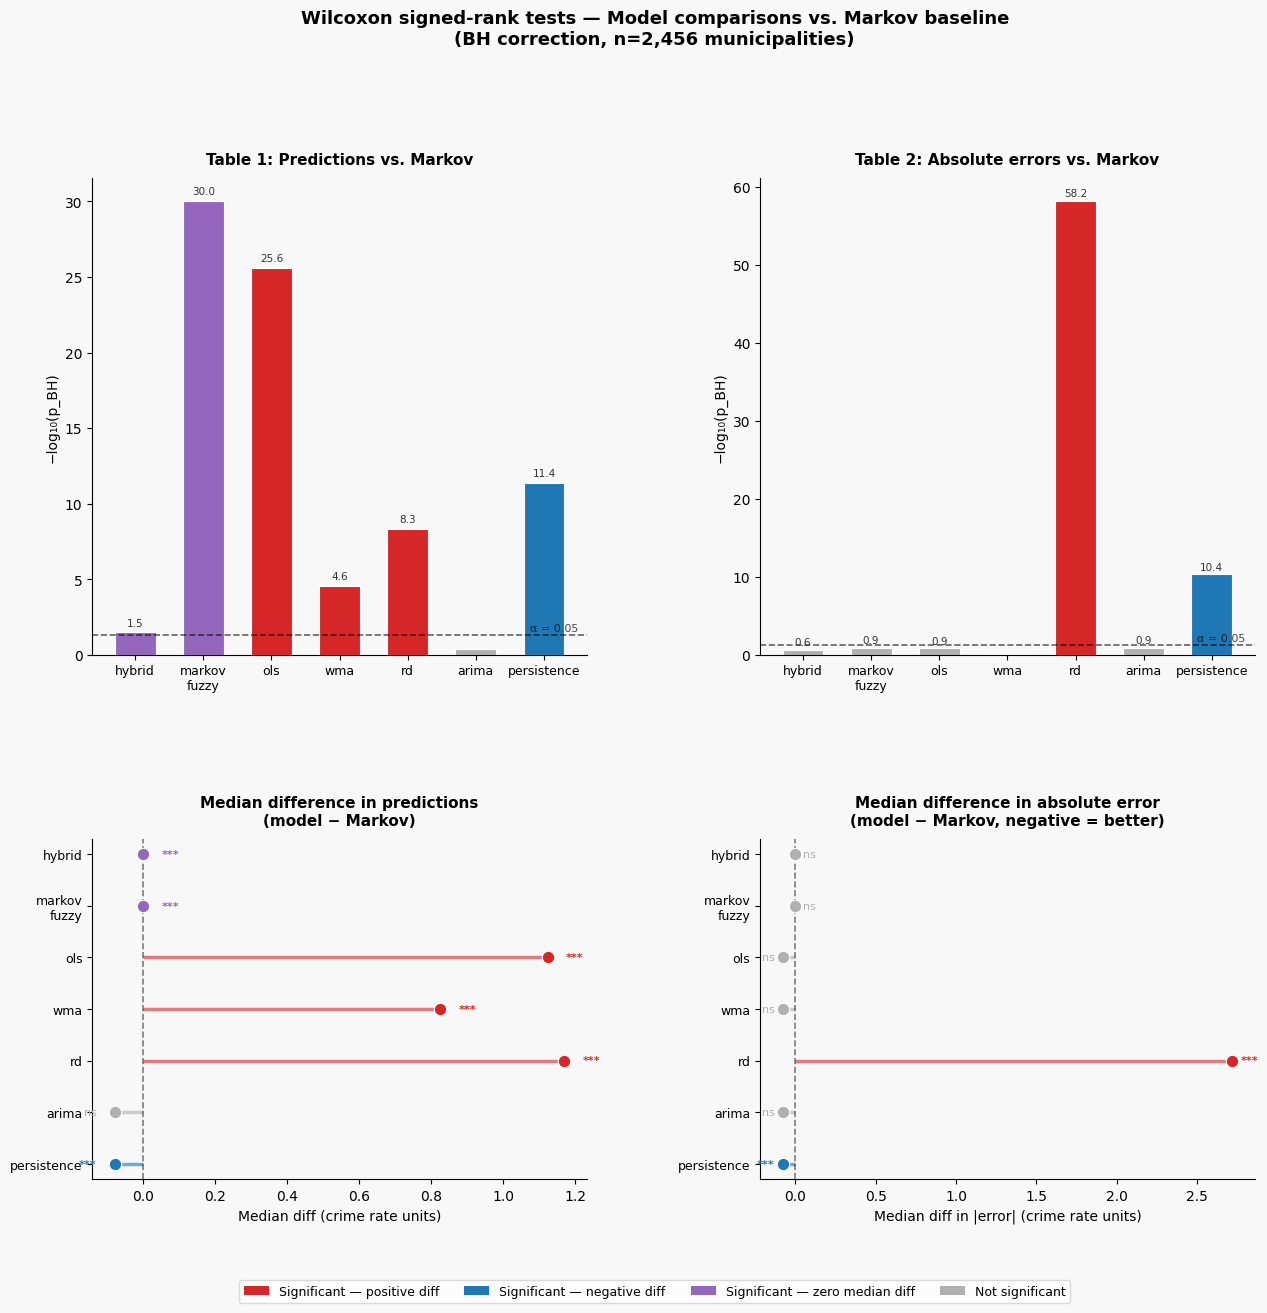

In [7]:
fig = plt.figure(figsize=(15, 13), facecolor='#f8f8f8')
gs  = GridSpec(2, 2, figure=fig, height_ratios=[1.4, 1],
               hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])   # -log10(p) bar — Table 1
ax2 = fig.add_subplot(gs[0, 1])   # -log10(p) bar — Table 2
ax3 = fig.add_subplot(gs[1, 0])   # forest plot   — median_diff Table 1
ax4 = fig.add_subplot(gs[1, 1])   # forest plot   — median_diff Table 2

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('#f8f8f8')
    ax.spines[['top', 'right']].set_visible(False)

x = np.arange(len(models))

# ── Panel 1 & 2: -log10(p_bh) bars ──────────────────────────────────────────
thresh = -np.log10(0.05)

for ax, df, colors, title in [
    (ax1, pred_df, pred_colors, 'Table 1: Predictions vs. Markov'),
    (ax2, err_df,  err_colors,  'Table 2: Absolute errors vs. Markov'),
]:
    log_p = [-np.log10(p) if p > 0 else 0 for p in df['p_bh']]
    bars  = ax.bar(x, log_p, color=colors, edgecolor='white', linewidth=0.8, width=0.6)
    ax.axhline(thresh, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.text(len(models) - 0.5, thresh + 0.15, 'α = 0.05', fontsize=8,
            ha='right', va='bottom', color='black', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(models_labels, fontsize=9)
    ax.set_ylabel('−log₁₀(p_BH)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

    # Value labels on bars
    for bar, lp in zip(bars, log_p):
        if lp > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{lp:.1f}', ha='center', va='bottom', fontsize=7.5, color='#333333')

# ── Panel 3 & 4: Forest / dot plots for median_diff ──────────────────────────
for ax, df, colors, title, xlabel in [
    (ax3, pred_df, pred_colors,
     'Median difference in predictions\n(model − Markov)',
     'Median diff (crime rate units)'),
    (ax4, err_df,  err_colors,
     'Median difference in absolute error\n(model − Markov, negative = better)',
     'Median diff in |error| (crime rate units)'),
]:
    for i, (_, row) in enumerate(df.iterrows()):
        col = colors[i]
        ax.scatter(row['median_diff'], i, color=col, s=80, zorder=4,
                   edgecolors='white', linewidths=0.8)
        ax.hlines(i, 0, row['median_diff'], colors=col, linewidths=2.5,
                  alpha=0.6)
        sig_label = '***' if row['significant'] else 'ns'
        ax.text(row['median_diff'] + (0.05 if row['median_diff'] >= 0 else -0.05),
                i, sig_label, va='center',
                ha='left' if row['median_diff'] >= 0 else 'right',
                fontsize=8, color=col,
                fontweight='bold' if row['significant'] else 'normal')

    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models_labels, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.invert_yaxis()

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=C_SIG_POS,  label='Significant — positive diff'),
    mpatches.Patch(facecolor=C_SIG_NEG,  label='Significant — negative diff'),
    mpatches.Patch(facecolor=C_SIG_ZERO, label='Significant — zero median diff'),
    mpatches.Patch(facecolor=C_NSIG,     label='Not significant'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.7, bbox_to_anchor=(0.5, 0.01))

fig.suptitle('Wilcoxon signed-rank tests — Model comparisons vs. Markov baseline\n(BH correction, n=2,456 municipalities)',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig(PRED_INF_GRAPHS_DIR/'wilcoxon_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()